In [1]:
!pip install ultralytics
print("✅ YOLO installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.3 MB/s eta 0:00:00
✅ YOLO installed!


In [2]:
from ultralytics import YOLO
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from google.colab import files
import urllib.request
import os

print("✅ All imports done!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All imports done!


In [3]:
print("⏳ Loading YOLO model...")
model = YOLO('yolov8n.pt')
print("✅ YOLOv8 model loaded!")

⏳ Loading YOLO model...
✅ YOLOv8 model loaded!


In [4]:
print("📁 Please upload an image...")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print(f"✅ Image uploaded: {image_path}")

📁 Please upload an image...


Saving OIP.webp to OIP.webp
✅ Image uploaded: OIP.webp



image 1/1 /content/OIP.webp: 416x640 1 cat, 295.7ms
Speed: 12.7ms preprocess, 295.7ms inference, 44.5ms postprocess per image at shape (1, 3, 416, 640)


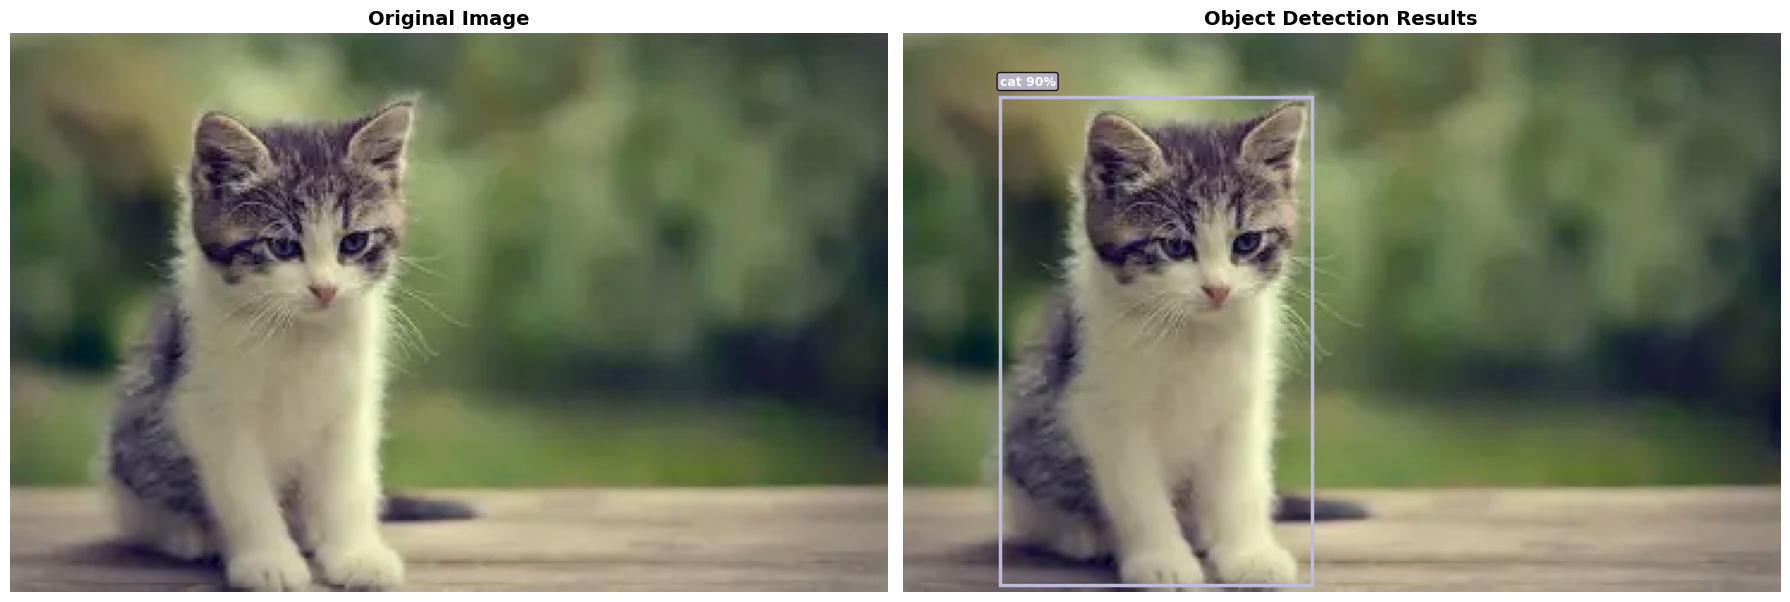


       🎯 Detection Results
  ✅ CAT                  × 1

  Total Objects Found: 1


In [5]:
def detect_objects(image_path):
    results = model(image_path, conf=0.25)
    result = results[0]
    img = np.array(Image.open(image_path).convert('RGB'))

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Original image
    axes[0].imshow(img)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Detection image
    axes[1].imshow(img)
    axes[1].set_title('Object Detection Results', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    colors = plt.cm.Set3(np.linspace(0, 1, 80))
    detections = []

    if result.boxes is not None:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            cls_id = int(box.cls[0])
            label = model.names[cls_id]
            color = colors[cls_id % len(colors)]

            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2.5, edgecolor=color, facecolor='none'
            )
            axes[1].add_patch(rect)
            axes[1].text(
                x1, y1-5, f'{label} {conf:.0%}',
                color='white', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.85)
            )
            detections.append({'label': label, 'confidence': conf, 'bbox': [x1,y1,x2,y2]})

    plt.tight_layout()
    plt.savefig('detection_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    return detections

detections = detect_objects(image_path)

print("\n" + "="*45)
print("       🎯 Detection Results")
print("="*45)
if detections:
    obj_counts = {}
    for d in detections:
        obj_counts[d['label']] = obj_counts.get(d['label'], 0) + 1
    for obj, count in sorted(obj_counts.items(), key=lambda x: -x[1]):
        print(f"  ✅ {obj.upper():<20} × {count}")
    print(f"\n  Total Objects Found: {len(detections)}")
else:
    print("  No objects detected. Try another image!")
print("="*45)

In [6]:
files.download('detection_result.png')
print("✅ Result image downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Result image downloaded!



image 1/1 /content/sample.jpg: 384x640 2 persons, 1 tie, 110.9ms
Speed: 1.6ms preprocess, 110.9ms inference, 5.7ms postprocess per image at shape (1, 3, 384, 640)


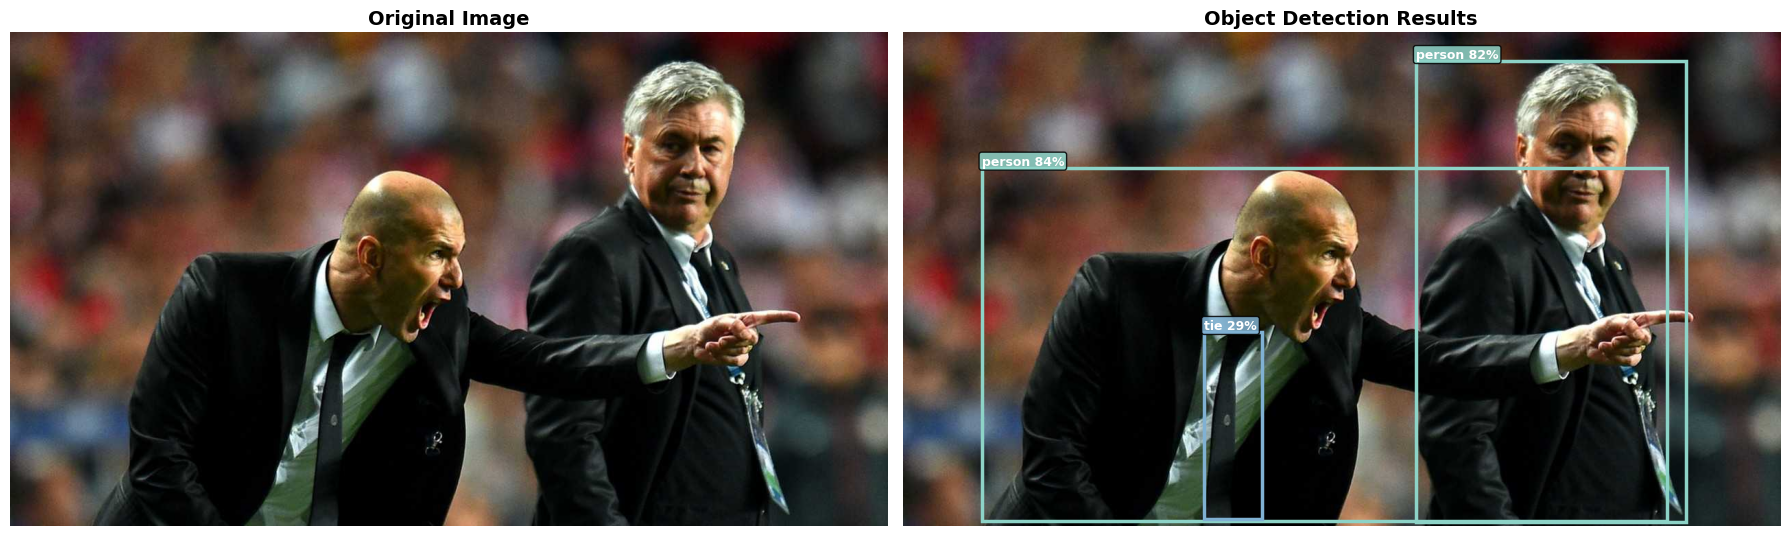

In [7]:
# Internet se sample image download karke test karo
url = "https://ultralytics.com/images/zidane.jpg"
urllib.request.urlretrieve(url, "sample.jpg")
detections = detect_objects("sample.jpg")